#  Avaliação Prática 2 
## Enzo Garofalo, Henry Piozzi, Yuri Balieiro

---
## Instalação e Imports

In [1]:
import torch
import torchvision
import torchvision.transforms as transforms
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from collections import Counter

torch.manual_seed(42)
np.random.seed(42)

---
## Etapa 1 - Leitura e Organização do Dataset

### 1.1  Carregar o CIFAR-10

In [2]:
CLASS_NAMES = [
    'airplane', 'automobile', 'bird', 'cat', 'deer',
    'dog', 'frog', 'horse', 'ship', 'truck'
]

transform_basic = transforms.ToTensor()

dataset_train_raw = torchvision.datasets.CIFAR10(
    root='./data',
    train=True,
    download=True,
    transform=transform_basic
)

dataset_test_raw = torchvision.datasets.CIFAR10(
    root='./data',
    train=False,
    download=True,
    transform=transform_basic
)

c:\Users\yuric\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\torchvision\datasets\cifar.py:83: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  entry = pickle.load(f, encoding="latin1")


### 1.2 -Shape dos dados

In [3]:
imagem_exemplo, label_exemplo = dataset_train_raw[0]

print(f"Shape de uma imagem (tensor): {imagem_exemplo.shape}")
print(f"Canais: {imagem_exemplo.shape[0]} (RGB)")
print(f"Altura: {imagem_exemplo.shape[1]} px")
print(f"Largura: {imagem_exemplo.shape[2]} px")
print(f"Total de amostras de Treino (original): {len(dataset_train_raw)}")
print(f"Total de amostras de Teste  (original): {len(dataset_test_raw)}")
print(f"Total de classes: {len(CLASS_NAMES)}")
print(f"Classes: {CLASS_NAMES}")

Shape de uma imagem (tensor): torch.Size([3, 32, 32])
Canais: 3 (RGB)
Altura: 32 px
Largura: 32 px
Total de amostras de Treino (original): 50000
Total de amostras de Teste  (original): 10000
Total de classes: 10
Classes: ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']


### 1.3 -10 amostras aleatórias com classe e miniatura

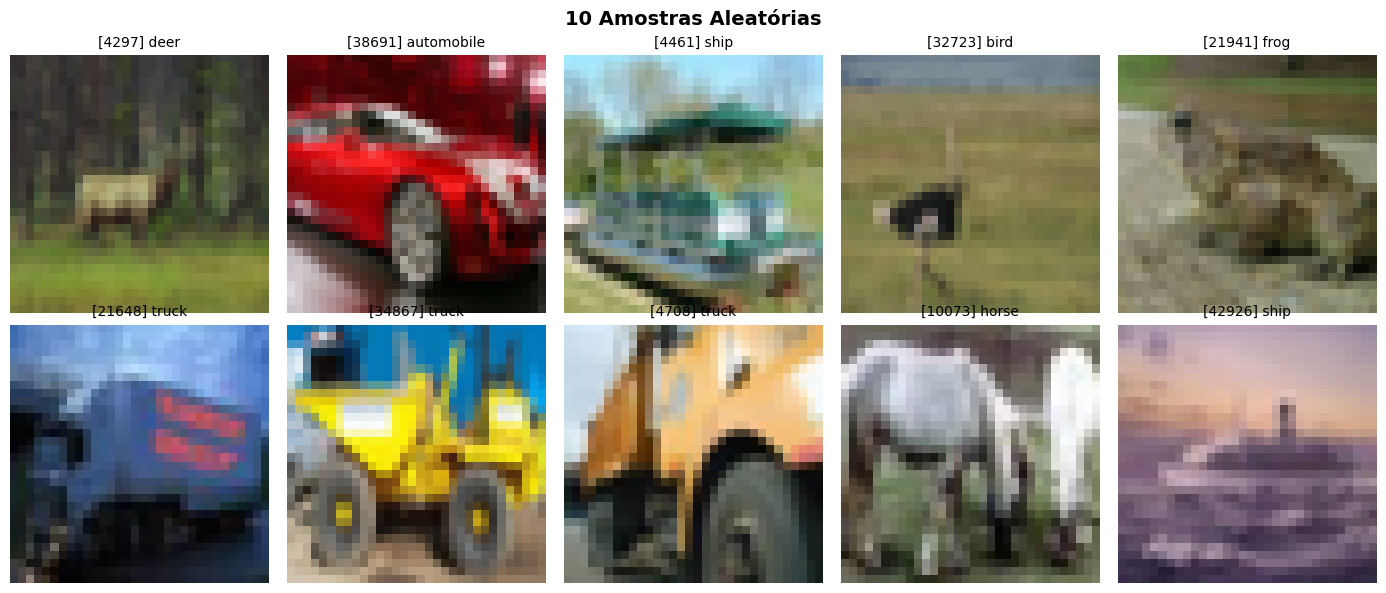

In [4]:
rng = np.random.default_rng(42)
indices_aleatorios = rng.choice(len(dataset_train_raw), size=10, replace=False)

fig, axes = plt.subplots(2, 5, figsize=(14, 6))
fig.suptitle('10 Amostras Aleatórias', fontsize=14, fontweight='bold')

for ax, idx in zip(axes.flat, indices_aleatorios):
    img_tensor, label = dataset_train_raw[idx]
    img_np = img_tensor.permute(1, 2, 0).numpy()
    ax.imshow(img_np)
    ax.set_title(f'[{idx}] {CLASS_NAMES[label]}', fontsize=10)
    ax.axis('off')

plt.tight_layout()
plt.show()

### 1.4 -Contagem de amostras por classe

In [5]:
labels_train = [dataset_train_raw[i][1] for i in range(len(dataset_train_raw))]
labels_test  = [dataset_test_raw[i][1]  for i in range(len(dataset_test_raw))]

contagem_treino = Counter(labels_train)
contagem_teste  = Counter(labels_test)

print(f"{'Classe':<14} {'Treino':>10} {'Teste':>10}")
for idx, nome in enumerate(CLASS_NAMES):
    print(f"{nome:<14} {contagem_treino[idx]:>10,} {contagem_teste[idx]:>10,}")
print(f"{'TOTAL':<14} {sum(contagem_treino.values()):>10,} {sum(contagem_teste.values()):>10,}")
print("\nDataset balanceado: 5.000 amostras por classe no treino e 1.000 no teste.")

Classe             Treino      Teste
airplane            5,000      1,000
automobile          5,000      1,000
bird                5,000      1,000
cat                 5,000      1,000
deer                5,000      1,000
dog                 5,000      1,000
frog                5,000      1,000
horse               5,000      1,000
ship                5,000      1,000
truck               5,000      1,000
TOTAL              50,000     10,000

Dataset balanceado: 5.000 amostras por classe no treino e 1.000 no teste.


C:\Users\yuric\AppData\Local\Temp\ipykernel_23592\2662777320.py:12: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(CLASS_NAMES, rotation=30, ha='right')
C:\Users\yuric\AppData\Local\Temp\ipykernel_23592\2662777320.py:12: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(CLASS_NAMES, rotation=30, ha='right')


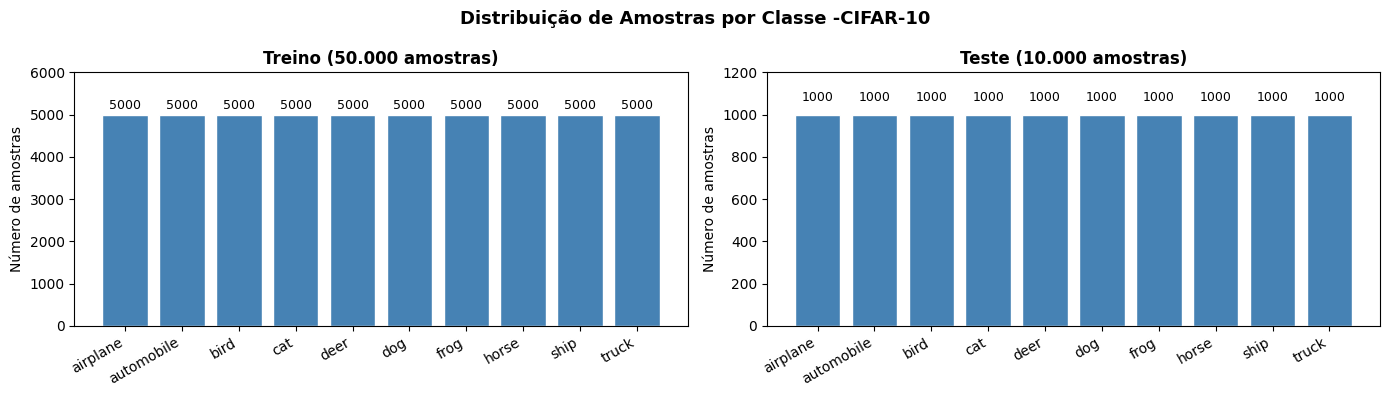

Figura salva em: distribuicao_classes.png


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

for ax, contagem, titulo in zip(
    axes,
    [contagem_treino, contagem_teste],
    ['Treino (50.000 amostras)', 'Teste (10.000 amostras)']
):
    valores = [contagem[i] for i in range(10)]
    bars = ax.bar(CLASS_NAMES, valores, color='steelblue', edgecolor='white')
    ax.set_title(titulo, fontweight='bold')
    ax.set_ylabel('Número de amostras')
    ax.set_xticklabels(CLASS_NAMES, rotation=30, ha='right')
    ax.set_ylim(0, max(valores) * 1.2)
    for bar, v in zip(bars, valores):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 50,
                str(v), ha='center', va='bottom', fontsize=9)

plt.suptitle('Distribuição de Amostras por Classe -CIFAR-10', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()
print("Figura salva em: distribuicao_classes.png")

---
## Etapa 2 -Pré-processamento e Data Augmentation

### 2.1 -Estatísticas dos canais (média e desvio padrão do CIFAR-10)

In [7]:
CIFAR10_MEAN = (0.4914, 0.4822, 0.4465)  # RGB
CIFAR10_STD  = (0.2470, 0.2435, 0.2616)  # RGB

print("Estatísticas canônicas do CIFAR-10 do conjunto de treino):")
for canal, m, s in zip(['R', 'G', 'B'], CIFAR10_MEAN, CIFAR10_STD):
    print(f"  Canal {canal}: média = {m:.4f} | desvio padrão = {s:.4f}")

print("Usado para padronização por canal z-score em treino, validação e teste.")

Estatísticas canônicas do CIFAR-10 do conjunto de treino):
  Canal R: média = 0.4914 | desvio padrão = 0.2470
  Canal G: média = 0.4822 | desvio padrão = 0.2435
  Canal B: média = 0.4465 | desvio padrão = 0.2616
Usado para padronização por canal z-score em treino, validação e teste.


### 2.2 -Definição dos transforms

In [8]:
transform_treino = transforms.Compose([
    transforms.RandomCrop(32, padding=4),
    transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(
        brightness=0.2,
        contrast=0.2,
        saturation=0.2,
        hue=0.05
    ),
    transforms.ToTensor(),
    transforms.Normalize(mean=CIFAR10_MEAN, std=CIFAR10_STD)
])

transform_val_teste = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=CIFAR10_MEAN, std=CIFAR10_STD)
])

print("Treino")
print(transform_treino)
print("Validação/Teste")
print(transform_val_teste)

Treino
Compose(
    RandomCrop(size=(32, 32), padding=4)
    RandomHorizontalFlip(p=0.5)
    ColorJitter(brightness=(0.8, 1.2), contrast=(0.8, 1.2), saturation=(0.8, 1.2), hue=(-0.05, 0.05))
    ToTensor()
    Normalize(mean=(0.4914, 0.4822, 0.4465), std=(0.247, 0.2435, 0.2616))
)
Validação/Teste
Compose(
    ToTensor()
    Normalize(mean=(0.4914, 0.4822, 0.4465), std=(0.247, 0.2435, 0.2616))
)


### 2.3 -Aplicar transforms e recarregar o dataset

In [9]:
dataset_treino_aug = torchvision.datasets.CIFAR10(
    root='./data',
    train=True,
    download=False,
    transform=transform_treino
)

dataset_val_teste = torchvision.datasets.CIFAR10(
    root='./data',
    train=True,
    download=False,
    transform=transform_val_teste
)

dataset_teste_final = torchvision.datasets.CIFAR10(
    root='./data',
    train=False,
    download=False,
    transform=transform_val_teste
)

print(f"  dataset_treino_aug {len(dataset_treino_aug)} amostras transform: treino (com augmentation)")
print(f"  dataset_val_teste {len(dataset_val_teste)} amostras transform: val/teste (só normalização)")
print(f"  dataset_teste_final {len(dataset_teste_final)} amostras transform: val/teste (só normalização)")

c:\Users\yuric\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\torchvision\datasets\cifar.py:83: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  entry = pickle.load(f, encoding="latin1")


  dataset_treino_aug 50000 amostras transform: treino (com augmentation)
  dataset_val_teste 50000 amostras transform: val/teste (só normalização)
  dataset_teste_final 10000 amostras transform: val/teste (só normalização)


### 2.4 -Verificação visual: imagem original vs. com augmentation

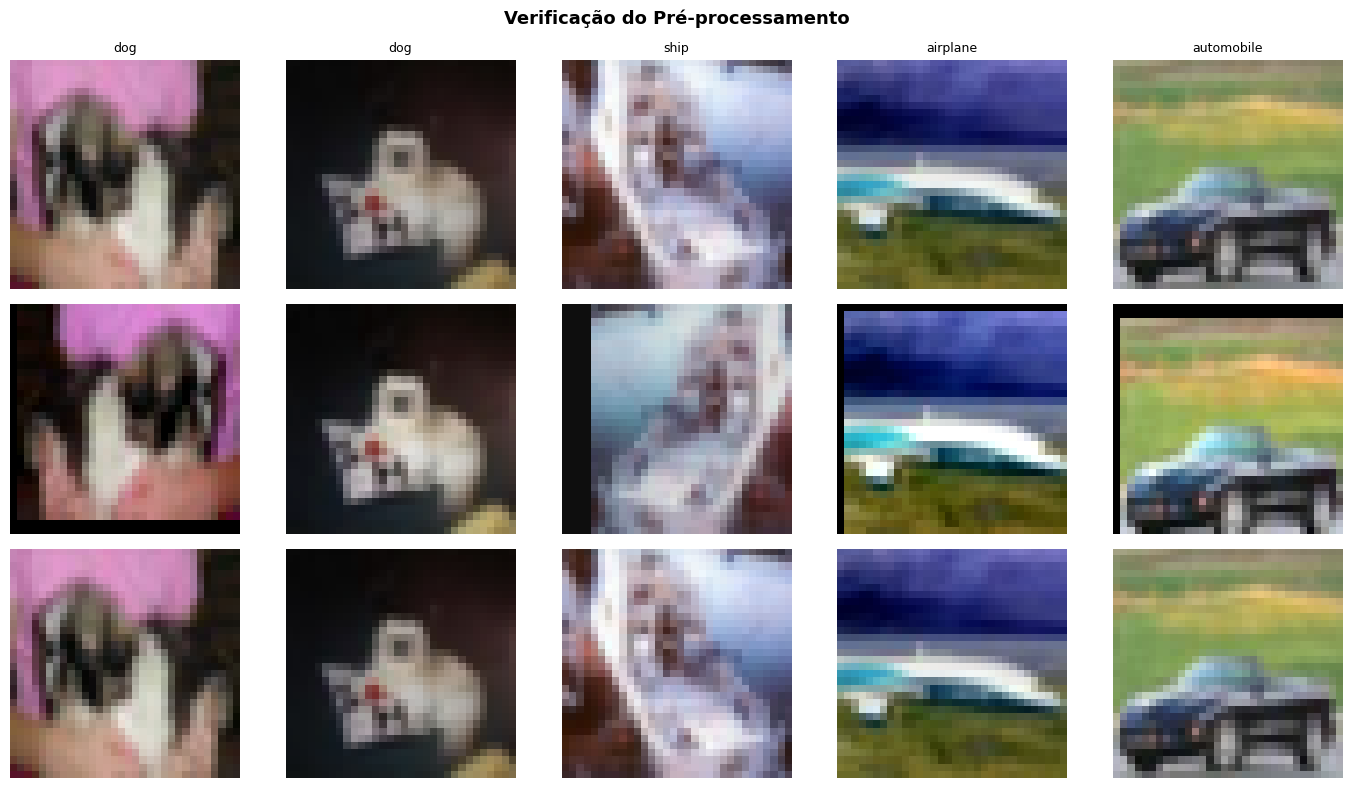

Figura salva em: verificacao_preproc.png


In [10]:
def desnormalizar(tensor, mean=CIFAR10_MEAN, std=CIFAR10_STD):
    img = tensor.clone()
    for c, (m, s) in enumerate(zip(mean, std)):
        img[c] = img[c] * s + m
    return img.clamp(0, 1)

rng2 = np.random.default_rng(42 + 1)
idx_amostras = rng2.choice(len(dataset_treino_aug), size=5, replace=False)

fig, axes = plt.subplots(3, 5, figsize=(14, 8))
fig.suptitle('Verificação do Pré-processamento', fontsize=13, fontweight='bold')

row_labels = ['Original\n(sem transform)', 'Augmentation\n(treino)', 'Só normalização\n(val/teste)']

for col, idx in enumerate(idx_amostras):
    img_orig, label = dataset_train_raw[idx]
    axes[0, col].imshow(img_orig.permute(1, 2, 0).numpy())
    if col == 0:
        axes[0, col].set_ylabel(row_labels[0], fontsize=9, rotation=90, labelpad=5)
    axes[0, col].set_title(CLASS_NAMES[label], fontsize=9)
    axes[0, col].axis('off')

    img_aug, _ = dataset_treino_aug[idx]
    axes[1, col].imshow(desnormalizar(img_aug).permute(1, 2, 0).numpy())
    if col == 0:
        axes[1, col].set_ylabel(row_labels[1], fontsize=9, rotation=90, labelpad=5)
    axes[1, col].axis('off')

    img_norm, _ = dataset_val_teste[idx]
    axes[2, col].imshow(desnormalizar(img_norm).permute(1, 2, 0).numpy())
    if col == 0:
        axes[2, col].set_ylabel(row_labels[2], fontsize=9, rotation=90, labelpad=5)
    axes[2, col].axis('off')

plt.tight_layout()
plt.show()
print("Figura salva em: verificacao_preproc.png")

### 2.5 -Verificação: shape e range após pré-processamento

In [11]:
img_check, _ = dataset_treino_aug[0]

print("Verificação Pós-Normalização")
print(f"Shape do tensor {img_check.shape}")
print(f"Dtype: {img_check.dtype}")
print(f"Valor mínimo: {img_check.min():.4f}")
print(f"Valor máximo: {img_check.max():.4f}")
print(f"Média (por canal): R={img_check[0].mean():.4f} | G={img_check[1].mean():.4f} | B={img_check[2].mean():.4f}")

Verificação Pós-Normalização
Shape do tensor torch.Size([3, 32, 32])
Dtype: torch.float32
Valor mínimo: -1.9895
Valor máximo: 2.1104
Média (por canal): R=0.1134 | G=-0.7453 | B=-0.9118


---
## Etapa 4 - Arquitetura da Rede (CNN)

In [13]:
import torch
import torch.nn as nn

class CIFAR10_CNN(nn.Module):
    def __init__(self):
        super(CIFAR10_CNN, self).__init__()

        self.layer1 = nn.Sequential(
            nn.Conv2d(in_channels=3,  out_channels=32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
            nn.Conv2d(in_channels=32, out_channels=32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2)  
        )
     
        self.layer2 = nn.Sequential(
            nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.Conv2d(in_channels=64, out_channels=64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2)   
        )
        
        self.head = nn.Sequential(
            nn.Dropout(p=0.3),
            nn.Flatten(),                          
            nn.Linear(64 * 8 * 8, 256),
            nn.ReLU(inplace=True),
            nn.Dropout(p=0.5),
            nn.Linear(256, 10)
        )

    def forward(self, x):
        x = self.layer1(x)
        x = self.layer2(x)
        x = self.head(x)
        return x


torch.manual_seed(42)

model = CIFAR10_CNN()
print(model)
print()

dummy = torch.randn(1, 3, 32, 32)
out = model(dummy)
print(f"Shape entrada : {dummy.shape}")   
print(f"Shape saída   : {out.shape}")     
print()

total     = sum(p.numel() for p in model.parameters())
treinaveis = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Parâmetros totais    : {total:,}")
print(f"Parâmetros treináveis: {treinaveis:,}")

CIFAR10_CNN(
  (layer1): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (5): ReLU(inplace=True)
    (6): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (layer2): Sequential(
    (0): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (5): ReLU(inplace=True)
    (6): MaxPool2d(kernel_size=2, stride